In [27]:
from dsc80_utils import *

# For the JSON evaluation example.
def err():
    raise ValueError('i just deleted all your files lol 😂')

# Lecture 9 – HTTP, Midterm Review

## DSC 80, Summer 2025

### Midterm Exam 📝

**Wednesday during the normal lecture slot.**

- 80 minutes long. If you arrive late, you will get less time to complete your exam!
- Pen / Pencil and paper only. No calculators, phones, or watches allowed.
- You are allowed to bring one double-sided 8.5" x 11" sheet of handwritten notes.
    - No reference sheet given, unlike DSC 10!
- Covers Lectures 1-8 and all related assignments: (Focus on Lectures, Labs and Project 1).
- To review problems from old exams, go to [practice.dsc80.com](https://practice.dsc80.com).

### Agenda 📆

- Introduction to HTTP.
- Making HTTP requests.
- Data formats.
- APIs and web scraping.
- Midterm review.

## Introduction to HTTP

<center><img src="imgs/ds-lifecycle.svg" width="60%"></center>

### Data sources

* Often, the data you need doesn't exist in "clean" `.csv` files.

* **Solution**: Collect your own data!
    - Design and administer your own survey or run an experiment.
    - Find related data on the internet.

- The internet contains **massive** amounts of historical record; for most questions you can think of, the answer exists somewhere on the internet.

### Collecting data from the internet

- There are two ways to programmatically access data on the internet:
    - through an API.
    - by scraping.

- We will discuss the differences between both approaches, but for now, the important part is that they **both use HTTP**.

### HTTP

- HTTP stands for **Hypertext Transfer Protocol**.
    - It was developed in 1989 by Tim Berners-Lee (and friends).

- It is a **request-response** protocol.
    - Protocol = set of rules.

- HTTP allows...
    - computers to talk to each other over a network.
    - devices to fetch data from "web servers."

- The "S" in HTTPS stands for "secure".

<center><img src='imgs/ucsd.png' width=750></center>

UCSD was a node in ARPANET, the predecessor to the modern internet ([source](https://en.wikipedia.org/wiki/ARPANET#/media/File:Arpanet_map_1973.jpg/)).

### The request-response model

HTTP follows the **request-response** model.

<center><img src='imgs/req-response.png' width=500></center>

- A <b><span style="color:blue">request</span></b> is made by the <b><span style="color:blue">client</span></b>.

- A <b><span style="color:orange">response</span></b> is returned by the <b><span style="color:orange">server</span></b>.

- **Example**: YouTube search 🎥.
    - Consider the following URL: https://www.youtube.com/results?search_query=apple+vision+pro.
    - Your web browser, a **client**, makes an HTTP **request** with a search query.
    - The **server**, YouTube, is a computer that is sitting somewhere else.
    - The server returns a **response** that contains the search results.
    - Note: ?search_query=apple+vision+pro is called a "query string."

### Request methods

The request methods you will use most often are `GET` and `POST`; see [Mozilla's web docs](https://developer.mozilla.org/en-US/docs/Web/HTTP/Methods) for a detailed list of request methods.    

- `GET` is used to request data **from** a specified resource.

- `POST` is used to **send** data to the server. 
    - For example, uploading a photo to Instagram or entering credit card information on Amazon.

### Example `GET` request

Below is an example `GET` HTTP request made by a browser when accessing [datascience.ucsd.edu](https://datascience.ucsd.edu).

```HTTP
GET / HTTP/1.1
Connection: keep-alive
Host: datascience.ucsd.edu
User-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36
sec-ch-ua: "Chromium";v="121", "Not A(Brand";v="99"
sec-ch-ua-platform: "macOS"
```

- The first line (`GET / HTTP/1.1`) is called the "request line", and the lines afterwards are called "header fields". Header fields contain metadata. 

- We _could_ also provide a "body" after the header fields.

- To see HTTP requests in Google Chrome, follow [these steps](https://mkyong.com/computer-tips/how-to-view-http-headers-in-google-chrome/).

### Example `GET` response

The response below was generated by executing the request on the previous slide.

```HTTP
HTTP/1.1 200 OK
Date: Sun, 04 Feb 2024 17:35:01 GMT
Server: Apache
X-Powered-By: PHP/7.4.33
Link: <https://datascience.ucsd.edu/wp-json/>; rel="https://api.w.org/"
Link: <https://datascience.ucsd.edu/wp-json/wp/v2/pages/113>; rel="alternate"; type="application/json"
...

<html lang="en-US">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
        <meta http-equiv="X-UA-Compatible" content="IE=edge">
        <link rel="profile" href="https://gmpg.org/xfn/11"/>
        <title>Halıcıoğlu Data Science Institute &#8211;UC San Diego</title>
        <script>
...
```

### Consequences of the request-response model

- When a request is sent to view content on a webpage, the server must:
    - process your request (i.e. prepare data for the response).
    - send content back to the client in its response.

- Remember, servers are computers. 
    - Someone has to pay to keep these computers running.
    - **This means that every time you access a website, someone has to pay.**

## Making HTTP requests

### Making HTTP requests

There are (at least) two ways to make HTTP requests outside of a browser:

- From the command line, with `curl`.

- **From Python, with the `requests` package.**

### Making HTTP requests using `requests`

- `requests` is a Python module that allows you to use Python to interact with the internet!  
- There are other packages that work similarly (e.g. `urllib`), but `requests` is arguably the easiest to use.

In [1]:
import requests

### Example: `GET` requests via `requests`

For instance, let's access the source code of the UCSD homepage, https://ucsd.edu.

In [2]:
res = requests.get('https://ucsd.edu')

`res` is now a `Response` object.

In [3]:
res

<Response [200]>

The `text` attribute of `res` is a string that containing the entire response.

In [6]:
type(res.text)


str

In [10]:
len(res.text)

62701

In [7]:
print(res.text[:3000])

<!DOCTYPE html>
<html lang="en">
  <head>
  
  

 





                                                        

    <meta charset="utf-8"/>
    <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
    <meta content="width=device-width, initial-scale=1" name="viewport"/>
    <title>University of California San Diego</title>
    <meta content="University of California, San Diego" name="ORGANIZATION"/>
    <meta content="index,follow,noarchive" name="robots"/>
    <meta content="UCSD" name="SITE"/>
    <meta content="University of California San Diego" name="PAGETITLE"/>
    <meta content="The University California San Diego is one of the world's leading public research universities, located in beautiful La Jolla, California" name="DESCRIPTION"/>
    <!-- Facebook -->
    <meta content="University of California San Diego" property="og:title"/>
    <meta content="The University California San Diego is one of the world's leading public research universities, located in beautiful La Joll

### Example: `POST` requests via `requests`

The following call to `requests.post` makes a post request to https://httpbin.org/post, with a `'name'` parameter of `'King Triton'`.

In [9]:
post_res = requests.post('https://httpbin.org/post',
                         data={'name': 'King Triton'})
post_res

<Response [200]>

In [10]:
post_res.text

'{\n  "args": {}, \n  "data": "", \n  "files": {}, \n  "form": {\n    "name": "King Triton"\n  }, \n  "headers": {\n    "Accept": "*/*", \n    "Accept-Encoding": "gzip, deflate, br, zstd", \n    "Content-Length": "16", \n    "Content-Type": "application/x-www-form-urlencoded", \n    "Host": "httpbin.org", \n    "User-Agent": "python-requests/2.32.3", \n    "X-Amzn-Trace-Id": "Root=1-68a38969-5ae86a8956ccef2548001dd4"\n  }, \n  "json": null, \n  "origin": "69.196.35.235", \n  "url": "https://httpbin.org/post"\n}\n'

In [11]:
# More on this shortly!
post_res.json()

{'args': {},
 'data': '',
 'files': {},
 'form': {'name': 'King Triton'},
 'headers': {'Accept': '*/*',
  'Accept-Encoding': 'gzip, deflate, br, zstd',
  'Content-Length': '16',
  'Content-Type': 'application/x-www-form-urlencoded',
  'Host': 'httpbin.org',
  'User-Agent': 'python-requests/2.32.3',
  'X-Amzn-Trace-Id': 'Root=1-68a38969-5ae86a8956ccef2548001dd4'},
 'json': None,
 'origin': '69.196.35.235',
 'url': 'https://httpbin.org/post'}

What happens when we try and make a `POST` request somewhere where we're unable to?

In [12]:
yt_res = requests.post('https://youtube.com',
                       data={'name': 'King Triton'})
yt_res

<Response [400]>

In [13]:
yt_res.text

'<html lang="en" dir="ltr"><head><title>Oops</title><style nonce="dM1b4AIsyzsJXYEpFVqN_Q">html{font-family:Roboto,Arial,sans-serif;font-size:14px}body{background-color:#f9f9f9;margin:0}#content{max-width:440px;margin:128px auto}svg{display:block;pointer-events:none}#monkey{width:280px;margin:0 auto}h1,p{text-align:center;margin:0;color:#131313}h1{padding:24px 0 8px;font-size:24px;font-weight:400}p{line-height:21px}sentinel{}</style><link rel="shortcut icon" href="https://www.youtube.com/img/favicon.ico" type="image/x-icon"><link rel="icon" href="https://www.youtube.com/img/favicon_32.png" sizes="32x32"><link rel="icon" href="https://www.youtube.com/img/favicon_48.png" sizes="48x48"><link rel="icon" href="https://www.youtube.com/img/favicon_96.png" sizes="96x96"><link rel="icon" href="https://www.youtube.com/img/favicon_144.png" sizes="144x144"></head><body><div id="content"><h1>Something went wrong</h1><p><svg id="monkey" viewBox="0 0 490 525"><path fill="#6A1B9A" d="M325 85c1 12-1 25-

`yt_res.text` is a string containing HTML – we can render this in-line using `IPython.display.HTML`.

In [14]:
from IPython.display import HTML

In [15]:
HTML(yt_res.text)

### HTTP status codes

- When we **request** data from a website, the server includes an **HTTP status code** in the response.  

* The most common status code is `200`, which means there were no issues.  

* Other times, you will see a different status code, describing some sort of event or error.
    - Common examples: `400` – bad request, `404` – page not found, `500` – internal server error.
    - [The first digit of a status describes its general "category".](https://developer.mozilla.org/en-US/docs/Web/HTTP/Status)

- See [https://httpstat.us](https://httpstat.us/) for a list of all HTTP status codes.
    - It also has example sites for each status code; for example, https://httpstat.us/404 returns a `404`.

In [16]:
yt_res.status_code

400

In [17]:
# ok checks if the result was successful.
yt_res.ok

False

### Handling unsuccessful requests

- Unsuccessful requests can be re-tried, depending on the issue.
    - A good first step is to wait a little, then try again.

- A common issue is that you're making too many requests to a particular server at a time – if this is the case, increase the time between each request. You can even do this programatically, say, using `time.sleep`.

- See the [textbook](https://learningds.org/ch/14/web_http.html) for more examples.

<div class="well">
    <h3>Ask <a href="https://chat.openai.com/">ChatGPT</a>: 🧐</h3>
    
- To explain why the `requests` library is useful to learn.
- To explain popular alternatives to the `requests` library and when you would prefer them to `requests`.
</div>

<div class="alert alert-warning">
    <h3>Question 🤔 (Answer at <a href="https://dsc80.com/q">dsc80.com/q</a>)</h3>

Code: `lec09-req`
</div>

Use ChatGPT to write code using the `requests` library to get the HTML of the `pandas` homepage. If the HTTP request fails, your code should print an error message and the error code.

## Data formats

### The data formats of the internet

Responses typically come in one of two formats: HTML or JSON.

- The response body of a `GET` request is usually either JSON (when using an API) or HTML (when accessing a webpage).

- The response body of a `POST` request is usually JSON.

- XML is also a common format, but not as popular as it once was.

<center><img src='imgs/json.png' width=50%></center>

### JSON

- JSON stands for **JavaScript Object Notation**. It is a lightweight format for storing and transferring data.

- It is:
    - very easy for computers to read and write.
    - moderately easy for programmers to read and write by hand.
    - meant to be generated and parsed.

- Most modern languages have an interface for working with JSON objects.
    - JSON objects _resemble_ Python dictionaries (but are not the same!).

### JSON data types

| Type | Description |
| --- | --- |
| String | Anything inside double quotes. |
| Number | Any number (no difference between ints and floats). |
| Boolean | `true` and `false`. |
| Null | JSON's empty value, denoted by `null`. |
| Array | Like Python lists. |
| Object | A collection of key-value pairs, like dictionaries. Keys must be strings, values can be anything (even other objects). |

See [json-schema.org](https://json-schema.org/understanding-json-schema/reference/type.html) for more details.

### Example JSON object

See `data/family.json`.

<center><img src='imgs/hierarchy.png' width=50%></center>

In [18]:
import json
from pathlib import Path

f = Path('data') / 'family.json'
family_tree = json.loads(f.read_text())

In [30]:
f.read_text()

'{\n    "name": "Grandma",\n    "age": 94,\n    "children": [\n        {\n        "name": "Dad",\n        "age": 60,\n        "children": [{"name": "Me", "age": 24}, \n                     {"name": "Brother", "age": 22}]\n        },\n        {\n        "name": "My Aunt",\n        "children": [{"name": "Cousin 1", "age": 34}, \n                     {"name": "Cousin 2", "age": 36, "children": \n                        [{"name": "Cousin 2 Jr.", "age": 2}]\n                     }\n                    ]\n        }\n    ]\n}'

In [19]:
f.read_text()

'{\n    "name": "Grandma",\n    "age": 94,\n    "children": [\n        {\n        "name": "Dad",\n        "age": 60,\n        "children": [{"name": "Me", "age": 24}, \n                     {"name": "Brother", "age": 22}]\n        },\n        {\n        "name": "My Aunt",\n        "children": [{"name": "Cousin 1", "age": 34}, \n                     {"name": "Cousin 2", "age": 36, "children": \n                        [{"name": "Cousin 2 Jr.", "age": 2}]\n                     }\n                    ]\n        }\n    ]\n}'

In [22]:
family_tree

{'name': 'Grandma',
 'age': 94,
 'children': [{'name': 'Dad',
   'age': 60,
   'children': [{'name': 'Me', 'age': 24}, {'name': 'Brother', 'age': 22}]},
  {'name': 'My Aunt',
   'children': [{'name': 'Cousin 1', 'age': 34},
    {'name': 'Cousin 2',
     'age': 36,
     'children': [{'name': 'Cousin 2 Jr.', 'age': 2}]}]}]}

In [21]:
family_tree['children'][1]['children'][0]['age']

34

In [34]:
family_tree['children'][1]['children'][0]['age']

34

### Aside: `eval`

- `eval`, which stands for "evaluate", is a function built into Python.

- It takes in a **string containing a Python expression** and evaluates it in the current context.

In [28]:
x = 4
eval('x + 5')

9

- It seems like `eval` can do the same thing that `json.loads` does...

In [23]:
eval(f.read_text())

{'name': 'Grandma',
 'age': 94,
 'children': [{'name': 'Dad',
   'age': 60,
   'children': [{'name': 'Me', 'age': 24}, {'name': 'Brother', 'age': 22}]},
  {'name': 'My Aunt',
   'children': [{'name': 'Cousin 1', 'age': 34},
    {'name': 'Cousin 2',
     'age': 36,
     'children': [{'name': 'Cousin 2 Jr.', 'age': 2}]}]}]}

- But you should **almost never use `eval`**. The next slide demonstrates why.

### `eval` gone wrong

Observe what happens when we use `eval` on a string representation of a JSON object:

In [25]:
f_other.read_text()

'{\n    "name": "Grandma",\n    "age": 94,\n    "children": [\n        {\n        "name": err(),\n        "age": 60,\n        "children": [{"name": "Me", "age": 24}, \n                     {"name": "Brother", "age": 22}]\n        },\n        {\n        "name": "My Aunt",\n        "children": [{"name": "Cousin 1", "age": 34}, \n                     {"name": "Cousin 2", "age": 36, "children": \n                        [{"name": "Cousin 2 Jr.", "age": 2}]\n                     }\n                    ]\n        }\n    ]\n}'

In [28]:
f_other = Path('data') / 'evil_family.json'
eval(f_other.read_text())

ValueError: i just deleted all your files lol 😂

In [37]:
f_other.read_text()

'{\n    "name": "Grandma",\n    "age": 94,\n    "children": [\n        {\n        "name": err(),\n        "age": 60,\n        "children": [{"name": "Me", "age": 24}, \n                     {"name": "Brother", "age": 22}]\n        },\n        {\n        "name": "My Aunt",\n        "children": [{"name": "Cousin 1", "age": 34}, \n                     {"name": "Cousin 2", "age": 36, "children": \n                        [{"name": "Cousin 2 Jr.", "age": 2}]\n                     }\n                    ]\n        }\n    ]\n}'

- Oh no! Since `evil_family.json`, which could have been downloaded from the internet, contained malicious code, we now lost all of our files.

- This happened because `eval` **evaluates** all parts of the input string as if it were Python code.

- You never need to do this – instead, use the `.json()` method of a response object, or use the `json` library.

### Using the `json` module

Let's process the same file using the `json` module. Note:
- `json.load(f)` loads a JSON file from a file object.
- `json.loads(f)` loads a JSON file from a **s**tring.

In [35]:
f_other = Path('data') / 'evil_family.json'
s = f_other.read_text()
s

'{\n    "name": "Grandma",\n    "age": 94,\n    "children": [\n        {\n        "name": err(),\n        "age": 60,\n        "children": [{"name": "Me", "age": 24}, \n                     {"name": "Brother", "age": 22}]\n        },\n        {\n        "name": "My Aunt",\n        "children": [{"name": "Cousin 1", "age": 34}, \n                     {"name": "Cousin 2", "age": 36, "children": \n                        [{"name": "Cousin 2 Jr.", "age": 2}]\n                     }\n                    ]\n        }\n    ]\n}'

In [33]:
json.loads(s)

JSONDecodeError: Expecting value: line 6 column 17 (char 84)

- Since `util.err()` is not a string in JSON (there are no quotes around it), `json.loads` is not able to parse it as a JSON object.

- This "safety check" is intentional.

### Handling _unfamiliar_ data

- Never trust data from an unfamiliar site.

- **Never** use `eval` on "raw" data that you didn't create!

- The JSON data format needs to be **parsed**, not evaluated as a dictionary.
    - It was designed with safety in mind!

### Aside: `pd.read_json`

`pandas` also has a built-in `read_json` function.

In [36]:
pd.read_json(f)

,name,age,children
0,Grandma,94,"{'name': 'Dad', 'age': 60, 'children': [{'name..."
1,Grandma,94,"{'name': 'My Aunt', 'children': [{'name': 'Cou..."


It only makes sense to use it, though, when you have a JSON file that has some sort of tabular structure. Our family tree example does not.

<div class="alert alert-warning">
    <h3>Question 🤔 (Answer at <a href="https://dsc80.com/q">dsc80.com/q</a>)</h3>

Code: `lec09-json`
</div>

Use ChatGPT to give you examples of inputs to `pd.read_json()` where the JSON reads successfully and unsuccessfully. What do you learn about `pd.read_json()`?

## APIs and scraping

### Programmatic requests

* We learned how to use the Python `requests` package to exchange data via HTTP.
    - `GET` requests are used to request data **from** a server.
    - `POST` requests are used to **send** data to a server.

* There are two ways of collecting data through a request:
    * By using a published API (application programming interface).
    * By scraping a webpage to collect its HTML source code.

### APIs

An application programming interface (API) is a service that makes data directly available to the user in a convenient fashion.

Advantages:

- The data are usually clean, up-to-date, and ready to use.

- The presence of a API signals that the data provider is okay with you using their data.

- The data provider can plan and regulate data usage.
    - Some APIs require you to create an API "key", which is like an account for using the API.
    - APIs can also give you access to data that isn't publicly available on a webpage.

Big disadvantage: APIs don't always exist for the data you want!

### API terminology

- A URL, or uniform resource locator, describes the location of a website or resource.

- An **API endpoint** is a URL of the data source that the user wants to make requests to.

- For example, on the [Reddit API](https://www.reddit.com/dev/api/):
    * the `/comments` endpoint retrieves information about comments.
    * the `/hot` endpoint retrieves data about posts labeled "hot" right now. 
    - To access these endpoints, you add the endpoint name to the base URL of the API.

### API requests

- API requests are just `GET`/`POST` requests to a specially maintained URL.
- Let's test out the [Pokémon API](https://pokeapi.co).

First, let's make a `GET` request for `'squirtle'`. To do this, we need to make a request to the correct URL.

In [37]:
def create_url(pokemon):
    return f'https://pokeapi.co/api/v2/pokemon/{pokemon}'

create_url('squirtle')

'https://pokeapi.co/api/v2/pokemon/squirtle'

In [38]:
r = requests.get(create_url('squirtle'))
r

<Response [200]>

Remember, the 200 status code is good! Let's take a look at the **content**:

In [39]:
r.content[:1000]

b'{"abilities":[{"ability":{"name":"torrent","url":"https://pokeapi.co/api/v2/ability/67/"},"is_hidden":false,"slot":1},{"ability":{"name":"rain-dish","url":"https://pokeapi.co/api/v2/ability/44/"},"is_hidden":true,"slot":3}],"base_experience":63,"cries":{"latest":"https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/latest/7.ogg","legacy":"https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/legacy/7.ogg"},"forms":[{"name":"squirtle","url":"https://pokeapi.co/api/v2/pokemon-form/7/"}],"game_indices":[{"game_index":177,"version":{"name":"red","url":"https://pokeapi.co/api/v2/version/1/"}},{"game_index":177,"version":{"name":"blue","url":"https://pokeapi.co/api/v2/version/2/"}},{"game_index":177,"version":{"name":"yellow","url":"https://pokeapi.co/api/v2/version/3/"}},{"game_index":7,"version":{"name":"gold","url":"https://pokeapi.co/api/v2/version/4/"}},{"game_index":7,"version":{"name":"silver","url":"https://pokeapi.co/api/v2/version/5/"}},{"game_index":7,

Looks like JSON. We can extract the JSON from this request with the `json` method (or by passing `r.text` to `json.loads`).

In [40]:
rr = r.json()
rr.keys()

dict_keys(['abilities', 'base_experience', 'cries', 'forms', 'game_indices', 'height', 'held_items', 'id', 'is_default', 'location_area_encounters', 'moves', 'name', 'order', 'past_abilities', 'past_types', 'species', 'sprites', 'stats', 'types', 'weight'])

In [41]:
rr['weight']

90

In [42]:
rr['abilities'][1]['ability']['name']

'rain-dish'

Let's try a `GET` request for `'billy'`.

In [43]:
r = requests.get(create_url('billy'))
r

<Response [404]>

We receive a 404 error, since there is no Pokemon named `'billy'`!

## NYT API RVEST

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# -------------------------------
# CONFIGURATION
# -------------------------------
NYTIMES_KEY = "OG89fUubcS8FXofVrLA4dmIOHh5omiFa"  # Replace with your key
term = "data+science"
begin_date = "20220119"
end_date = "20230202"

# -------------------------------
# BUILD URL AND INITIAL QUERY
# -------------------------------
base_url = f"https://api.nytimes.com/svc/search/v2/articlesearch.json?q={term}&begin_date={begin_date}&end_date={end_date}&facet_filter=true&api-key={NYTIMES_KEY}"

print(base_url)

# Initial query to get total hits
initial_response = requests.get(base_url).json()

initial_response

hits = initial_response['response']['metadata']['hits']

hits

In [48]:
max_pages = min((hits // 10), 100)  # NYT API only allows first 100 pages

print(f"Total articles found: {hits}")
print(f"Fetching {max_pages} pages...")

# -------------------------------
# PAGINATED API CALLS
# -------------------------------
all_articles = []

for page in range(max_pages):
    url = f"{base_url}&page={page}"
    print(f"Fetching page {page}...")
    response = requests.get(url).json()
    docs = response['response']['docs']
    all_articles.extend(docs)
    time.sleep(5)  # Respect NYT rate limits

print(f"Finished Fetching Articles")

# Convert to DataFrame
df = pd.json_normalize(all_articles)
df

Total articles found: 1254
Fetching 100 pages...
Fetching page 0...
Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...


KeyError: 'response'

/var/folders/mf/_kslmvz17wvg8hpdn2509ymw0000gq/T/ipykernel_32613/4236158888.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_trim, y='type_of_material', order=df_trim['type_of_material'].value_counts().index, palette="tab10")


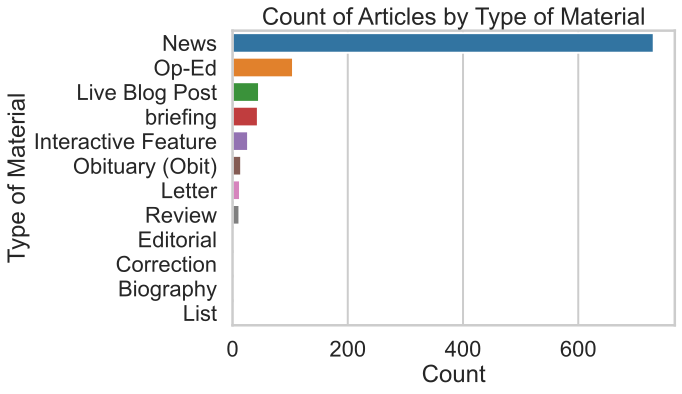

/var/folders/mf/_kslmvz17wvg8hpdn2509ymw0000gq/T/ipykernel_32613/4236158888.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_counts, y='type_of_material', x='percent', palette="tab10")


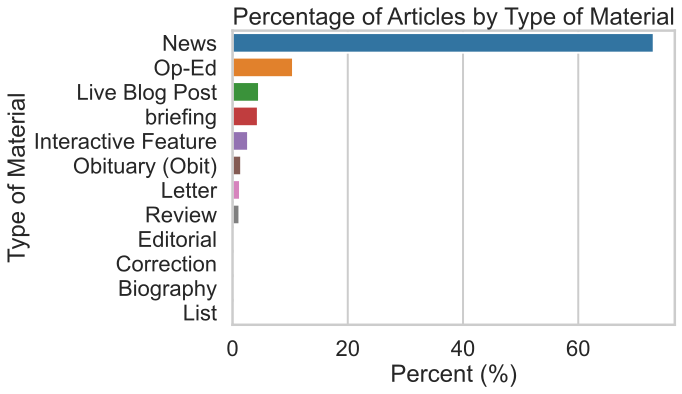

In [104]:

# -------------------------------
# DATA WRANGLING
# -------------------------------
# Keep only relevant columns
df_trim = df[['type_of_material', 'section_name', 'headline.main', 'pub_date']].copy()
df_trim['pub_date'] = pd.to_datetime(df_trim['pub_date'])

# -------------------------------
# PLOT: Count of Articles by Type
# -------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df_trim, y='type_of_material', order=df_trim['type_of_material'].value_counts().index, palette="tab10")
plt.title("Count of Articles by Type of Material")
plt.xlabel("Count")
plt.ylabel("Type of Material")
plt.tight_layout()
plt.show()

# -------------------------------
# PLOT: Percent of Articles by Type
# -------------------------------
type_counts = df_trim['type_of_material'].value_counts().reset_index()
type_counts.columns = ['type_of_material', 'count']
type_counts['percent'] = 100 * type_counts['count'] / type_counts['count'].sum()

plt.figure(figsize=(10, 6))
sns.barplot(data=type_counts, y='type_of_material', x='percent', palette="tab10")
plt.title("Percentage of Articles by Type of Material")
plt.xlabel("Percent (%)")
plt.ylabel("Type of Material")
plt.tight_layout()
plt.show()

## Scraping

Scraping is the act of programmatically "browsing" the web, downloading the source code (HTML) of pages that you're interested in extracting data from.

Big advantage: You can always do it! For example, Google scrapes webpages in order to make them searchable.

Disadvantages:

- It is often difficult to parse and clean scraped data.
    - Source code often includes a lot of content unrelated to the data you're trying to find (e.g. formatting, advertisements, other text).

- Websites can change often, so scraping code can get outdated quickly.

- Websites may not want you to scrape their data!

- **In general, we prefer APIs, but scraping is a useful skill to learn.**

### Example: Dallas Temperature
 https://www.weather.gov/fwd/dmotemp

In [50]:
pip install lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 44.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [49]:
import requests
import pandas as pd
from lxml import html

# Step 1: Get the HTML content
url = "https://www.weather.gov/fwd/dmotemp"
response = requests.get(url)
tree = html.fromstring(response.content)

# Step 2: Use XPath to extract the specific table
# This XPath matches the one you used in R:
xpath_str = '//*[@id="pagebody"]/div[3]/div/table'
table_element = tree.xpath(xpath_str)[0]

# Step 3: Convert to string and parse with pandas
html_string = html.tostring(table_element, encoding='unicode')
df = pd.read_html(html_string)[0]

# Preview
print(df.head())


   Year   Jan   Feb   Mar  ...   Oct   Nov   Dec  Total
0  2025  42.9  49.3  64.0  ...   NaN   NaN   NaN    NaN
1  2024  43.0  57.7  61.8  ...  75.7  61.7  53.7   69.8
2  2023  52.1  52.4  60.7  ...  69.2  57.8  52.8   69.7
3  2022  45.8  46.2  58.5  ...  69.1  55.0  50.7   68.2
4  2021  47.5  41.1  61.4  ...  72.0  57.7  61.3   67.5

[5 rows x 14 columns]


/var/folders/mf/_kslmvz17wvg8hpdn2509ymw0000gq/T/ipykernel_40847/899380283.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html_string)[0]


In [50]:
# Step 2: Flip the data (columns Dec to Jan), then flatten
monthly_data = df.iloc[:, 1:13]    # Drop the first column (likely "Year")
monthly_data = monthly_data.iloc[:, ::-1]  # Reverse columns: Dec → Jan

# Flatten to a 1D array (from earliest to latest)
flat_data = monthly_data.to_numpy().flatten()[::-1]

# Step 3: Clean and interpolate
series = pd.to_numeric(pd.Series(flat_data), errors='coerce')
series_trimmed = series[series.first_valid_index():series.last_valid_index()]
series_interp = series_trimmed.interpolate(method='linear').reset_index(drop=True)

# Final time series
dallas_temp = series_interp

# Step 4: Create time index starting Sep 1898
dates = pd.date_range(start='1898-09', periods=len(dallas_temp), freq='M')



/var/folders/mf/_kslmvz17wvg8hpdn2509ymw0000gq/T/ipykernel_40847/618050727.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='1898-09', periods=len(dallas_temp), freq='M')


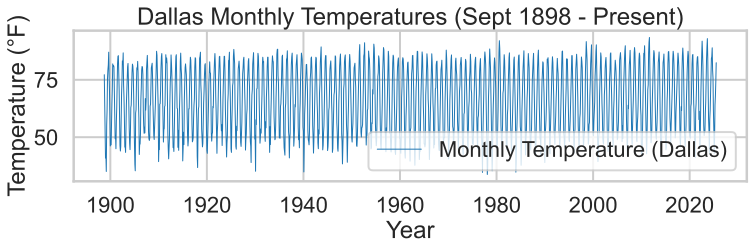

In [51]:
# Step 5: Plot the time series
plt.figure(figsize=(11, 4))
plt.plot(dates, dallas_temp, label='Monthly Temperature (Dallas)', linewidth=1)
plt.title('Dallas Monthly Temperatures (Sept 1898 - Present)')
plt.xlabel('Year')
plt.ylabel('Temperature (°F)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Example: Scraping the HDSI faculty page

To fully understand how to scrape, we need to understand how HTML documents are structured and how to extract information out of them.

But as a preview of what's to come next week, let's start by making a request to the HDSI Faculty page, https://datascience.ucsd.edu/faculty.

In [56]:
import certifi
certifi.where()

'/Users/bsadler/Desktop/ls/envs/dsc80/lib/python3.12/site-packages/certifi/cacert.pem'

In [57]:
# Sometimes, the requests library gets weirdly strict about the HDSI webpage,
# so we'll skip its security checks using verify=False.
fac_response = requests.get('https://datascience.ucsd.edu/faculty/', verify=False)
fac_response

/Users/bsadler/Desktop/ls/envs/dsc80/lib/python3.12/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'datascience.ucsd.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


<Response [200]>

The response is a long HTML document.

In [58]:
len(fac_response.text)

253518

In [59]:
print(fac_response.text[:1000])

<!DOCTYPE html><html lang="en-US"><head><meta charset="UTF-8"><meta name="viewport" content="width=device-width, initial-scale=1.0" /><meta http-equiv="X-UA-Compatible" content="IE=edge"><link rel="profile" href="https://gmpg.org/xfn/11" /><title>Faculty &#8211; Halıcıoğlu Data Science Institute &#8211; UC San Diego</title> <script defer src="data:text/javascript;base64,CiAgICAgICAgICAgICAgICAgICAgICAgICAgICAvKiBZb3UgY2FuIGFkZCBtb3JlIGNvbmZpZ3VyYXRpb24gb3B0aW9ucyB0byB3ZWJmb250bG9hZGVyIGJ5IHByZXZpb3VzbHkgZGVmaW5pbmcgdGhlIFdlYkZvbnRDb25maWcgd2l0aCB5b3VyIG9wdGlvbnMgKi8KICAgICAgICAgICAgICAgICAgICAgICAgICAgIGlmICggdHlwZW9mIFdlYkZvbnRDb25maWcgPT09ICJ1bmRlZmluZWQiICkgewogICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgIFdlYkZvbnRDb25maWcgPSBuZXcgT2JqZWN0KCk7CiAgICAgICAgICAgICAgICAgICAgICAgICAgICB9CiAgICAgICAgICAgICAgICAgICAgICAgICAgICBXZWJGb250Q29uZmlnWydnb29nbGUnXSA9IHtmYW1pbGllczogWydSb2JvdG86NDAwLDUwMCcsICdKb3N0OjQwMCw3MDAnLCAnVGVrbzo3MDAnXX07CgogICAgICAgICAgICAgICAgICAgICAgICAgICAgKGZ1bmN0aW9uKCk

<div class="alert alert-warning">
    <h3>Question 🤔 (Answer at <a href="https://dsc80.com/q">dsc80.com/q</a>)</h3>

Code: `lec09-fac`
</div>
    
Try asking ChatGPT to get the faculty names from this webpage by pasting the HTML of `fac_response` into the prompt. What happens? Can you figure out a way to get around this?

To **parse** HTML, we'll use the BeautifulSoup library.

In [60]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(fac_response.text)

Now, `soup` is a representation of the faculty page's HTML code that Python knows how to extract information from.

In [ ]:
# Magic that we'll learn how to create together next Tuesday.
divs = soup.find_all('div', class_='vc_grid-item')
names = [div.find('h4').text for div in divs]
titles = [div.find(class_='pendari_people_title').text for div in divs]

faculty = pd.DataFrame({
    'name': names, 
    'title': titles, 
})
faculty.head()

Now we have a DataFrame!

In [ ]:
faculty[faculty['title'].str.contains('Lecturer') | faculty['title'].str.contains('Teaching')]

What if we want to get faculty members' pictures? 

In [ ]:
from IPython.display import Image, display

def show_picture(name):
    idx = faculty[faculty['name'].str.lower().str.contains(name.lower())].index[0]
    display(Image(url=divs[idx].find('img')['src'], width=200, height=200))

In [ ]:
show_picture('duncan')

<div class="alert alert-warning">
    <h3>Question 🤔 (Answer at <a href="https://dsc80.com/q">dsc80.com/q</a>)</h3>

Code: `lec09-imgs`
</div>
    
Write a prompt so that ChatGPT generates `bs4` code to correctly pull out the `img` tags from the HDSI Faculty HTML.

p.s. We'll go into much more detail on this on Thursday!